<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumno:} & Escobar Gonzalez Isaac Giovani \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

In [18]:
# @title Ejercicios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')



---


## Fórmulas de métricas de clasificación

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}
$$

Donde:
- TP = Verdaderos positivos (Predijo SI, Real SI)
- TN = Verdaderos negativos (Predijo NO, Real No)
- FP = Falsos positivos (Predijo SI, Real NO)
- FN = Falsos negativos (Predijo NO, Real SI)

Tablita:
|            | Pred: Sí | Pred: No |
|------------|----------|----------|
| **Real: Sí**   | (TP) | (FN)   |
| **Real: No**   | (FP) |  (TN)  |

---



# Ejercicio 1. Matriz de confusión + métricas


## Construccion básica: Se tiene el siguiente resultado de un clasificador binario
- TP = 50
- FP = 10
- FN = 5
- TN = 35

1. Construye la Matriz de confusión.
$$
M = \begin{pmatrix} TN & FP \\ FN & TP \end{pmatrix}
= \begin{pmatrix} 35 & 10 \\ 5 & 50 \end{pmatrix}
$$

In [ ]:
# 2. Cálculo de métricas
TP = 50
FP = 10
FN = 5
TN = 35

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1-score  = {f1:.4f}")

Accuracy  = 0.8500
Precision = 0.8333
Recall    = 0.9091
F1-score  = 0.8696


3. Discusión: ¿Qué métrica es más importante en detección de enfermedad?

La métrica más importante es el Recall,
Queremos minimizar los falsos negativos (enfermos que el modelo clasifica como sanos).
Un falso negativo puede retrasar el tratamiento y poner en riesgo la vida del paciente.
Un falso positivo es menos grave, solo genera estudios adicionales.

---



# Ejercicio 2. Métricas con desbalance de clases

## Dataset médico: Detección de enfermedad (Solo 5% positivos)
|            | Pred: Sí | Pred: No |
|------------|----------|----------|
| **Real: Sí**   | 8 (TP)   | 2 (FN)   |
| **Real: No**   | 90 (FP)  | 900 (TN)  |



In [12]:
#Cálculo de métricas
TP = 8
FP = 90
FN = 2
TN = 900

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1-score  = {f1:.4f}")

Accuracy  = 0.9080
Precision = 0.0816
Recall    = 0.8000
F1-score  = 0.1481


1. **¿Accuracy es buena métrica aquí?**

En datasets desbalanceados, el Accuracy es engañoso, pese al 90.8%, de 98 positivos totales, solo 8 eran correctos. El modelo está alarmando mucha gente sana.

2. ** Calcula Recall y Precision.**

Precision = 0.0816 - 8%


Recall    = 0.8000 - 80%

3. ** ¿Que métrica priorizarias y por qué? **

Recall, porque es deteccion de enfermedad, queremos minimizar FN

4. ** ¿Es un buen modelo? Por qué? **

No. Pese a que tiene un Recall aceptable y detecta a la mayoria de enfermos, su precisión es baja y genera gran cantidad de falsos positivos.

---





---


#**Metricas para errores en regresión**

Error Absoluto Medio: promedio de los errores absolutos
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

Error Cuadrático Medio: Eleva cada error al cuadrado, luego promedia.
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


---



# Ejercicio 3. Error en regresión (MSE vs MAE)



## Predicciones de Precios
**Tabla de predicciones:**

| Real | Pred |
|------|------|
| 100  | 90   |
| 200  | 210  |
| 300  | 1000 |


**Cálculo paso a paso de MSE y MAE:**

1. **Errores absolutos (para MAE):**
   - |100 - 90| = 10
   - |200 - 210| = 10
   - |300 - 1000| = 700

   $$
   MAE = \frac{10 + 10 + 700}{3} = \frac{720}{3} = 240
   $$

2. **Errores al cuadrado (para MSE):**
   - (100 - 90)² = 10² = 100
   - (200 - 210)² = (-10)² = 100
   - (300 - 1000)² = (-700)² = 490,000

   $$
   MSE = \frac{100 + 100 + 490000}{3} = \frac{490200}{3} = 163,400
   $$

**Pregunta de reflexión:** ¿Cuál penaliza más los errores grandes?

**Respuesta:** El **MSE** penaliza más los errores grandes porque al elevar al cuadrado, las diferencias grandes se magnifican (como el error de 700 → 490,000). En cambio, el MAE trata todos los errores de forma lineal.

In [13]:
# Datos
real = [100, 200, 300]
pred = [90, 210, 1000]

# Cálculo
n = len(real)
errores_abs = [abs(r - p) for r, p in zip(real, pred)]
mae = sum(errores_abs) / n

errores_cuad = [(r - p)**2 for r, p in zip(real, pred)]
mse = sum(errores_cuad) / n

print("MAE =", mae)
print("MSE =", mse)

MAE = 240.0
MSE = 163400.0
El MSE penaliza más los errores grandes porque eleva al cuadrado.


**3. ¿Cuál penaliza más los errores grandes?**

El **MSE** penaliza más los errores grandes porque al elevar al cuadrado, las diferencias grandes se magnifican (como el error de 700 → 490,000). En cambio, el MAE trata todos los errores de forma lineal.

---



# Ejercicio 4. Regresión lineal.


##Interpretación de coeficientes.
**Modelo dado:**

$$
y = 5 + 2x_1 - 3x_2
$$

**1. Interpretación de cada coeficiente:**

- **Intercepto = 5**  
  Cuando \( x_1 = 0 \) y \( x_2 = 0 \), el valor esperado de \( y \) es 5. Es el punto de partida del modelo.

- **Coeficiente de \( x_1 = 2 \)**  
  Por cada unidad que aumenta \( x_1 \), \( y \) aumenta en 2 unidades (manteniendo \( x_2 \) constante).

- **Coeficiente de \( x_2 = -3 \)**  
  Por cada unidad que aumenta \( x_2 \), \( y \) disminuye en 3 unidades (manteniendo \( x_1 \) constante).

**2. ¿Qué pasa si \( x_2 \) aumenta?**  
Como el coeficiente es negativo (−3), un aumento en \( x_2 \) produce una **disminución** en \( y \). Por ejemplo, si \( x_2 \) aumenta en 1 unidad, \( y \) se reduce en 3 unidades.

---



# Ejercicio 5. Regresión logística.




## Modelo:
$$
P(y = 1 \mid x) = \frac{1}{1 + e^{-(2x - 4)}}
$$

P(y=1 | x=2) = 0.5000
Umbral exacto: modelo incierto


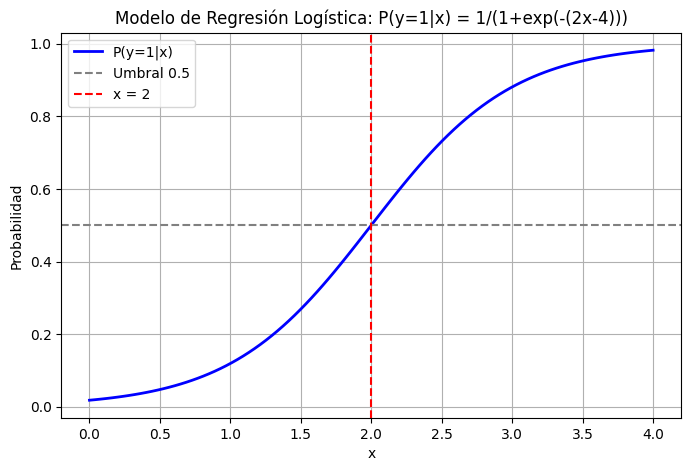

In [17]:
# Definimos el modelo.
def probabilidad(x):
    return 1 / (1 + np.exp(-(2*x - 4)))

# Probar x = 2
x_prueba = 2
prob = probabilidad(x_prueba)
print(f"P(y=1 | x={x_prueba}) = {prob:.4f}")

# Umbral de decisión
if prob > 0.5:
    print("Predicción: clase 1")
elif prob < 0.5:
    print("Predicción: clase 0")
else:
    print("Umbral exacto: modelo incierto")

# Visualizar la curva sigmoide
x_vals = np.linspace(0, 4, 100)
p_vals = probabilidad(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, p_vals, 'b-', linewidth=2, label='P(y=1|x)')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.axvline(2, color='red', linestyle='--', label='x = 2')
plt.xlabel('x')
plt.ylabel('Probabilidad')
plt.title('Modelo de Regresión Logística: P(y=1|x) = 1/(1+exp(-(2x-4)))')
plt.legend()
plt.grid(True)
plt.show()


**1. ¿Que pasa cuando  x=2?**

 P(y=1 | x=2) = 0.5000

 **2. Cual es el umbral de decisión? **

En regresión logística, el umbral típico es **0.5**:

- Si \( P > 0.5 \) → se predice clase \( y = 1 \)
- Si \( P < 0.5 \) → se predice clase \( y = 0 \)


Con x=2 siendo el umbral de decisión:

- Si \( x > 2 \) → La probabilidad será payor a 0.5, el modelo predice la clase 1.

- Si \( x < 2 \) → La probabilidad será payor a 0.5, el modelo predice la clase 1.


**3. ¿Qué significa el coeficiente 2?**
Por cada unidad que aumenta x, aumenta la tendencia del modelo hacia la clase positiva, incremntando la posibilidad de que eel resultado sea y=1. El 2 determina la pendiente o crecimiento de la curva.

---


